In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/prakharkishore/bmw-xl/bmw_sales_dataset.xlsx


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: Makes plots look nicer
plt.style.use("ggplot")

# Display all columns
pd.set_option("display.max_columns", None)

In [6]:
df = pd.read_excel("/kaggle/input/datasets/prakharkishore/bmw-xl/bmw_sales_dataset.xlsx")

In [7]:
df.head()

,Model,Region,Units Sold,Price,Cost,Profit
0,BMW 3 Series,North,15,84343,63228.963133,316710.553003
1,BMW X3,East,11,51962,42429.261222,104860.126561
2,BMW 3 Series,West,3,31685,19457.850220,36681.449339
3,BMW 3 Series,South,6,32433,20934.082290,68993.506258
4,BMW 5 Series,North,12,49769,36390.550711,160541.391462


In [8]:
df.info()

df.describe()

df.head()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Model       200 non-null    object 
 1   Region      200 non-null    object 
 2   Units Sold  200 non-null    int64  
 3   Price       200 non-null    int64  
 4   Cost        200 non-null    float64
 5   Profit      200 non-null    float64
dtypes: float64(2), int64(2), object(2)
memory usage: 9.5+ KB


Model         0
Region        0
Units Sold    0
Price         0
Cost          0
Profit        0
dtype: int64

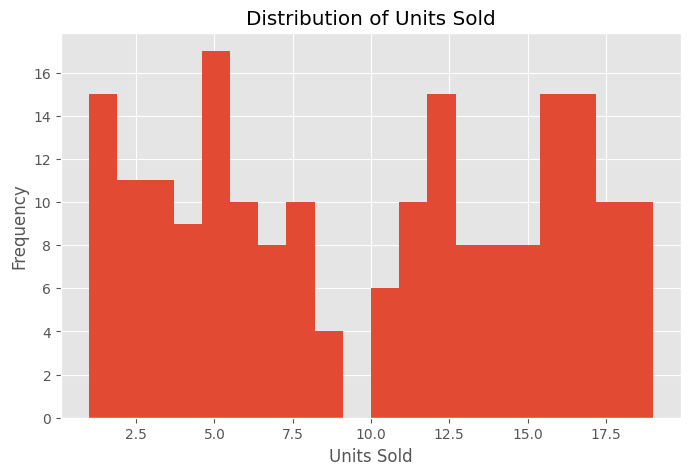

In [9]:
plt.figure(figsize=(8,5))

plt.hist(df["Units Sold"],bins=20)

plt.title("Distribution of Units Sold")

plt.xlabel("Units Sold")

plt.ylabel("Frequency")

plt.show()

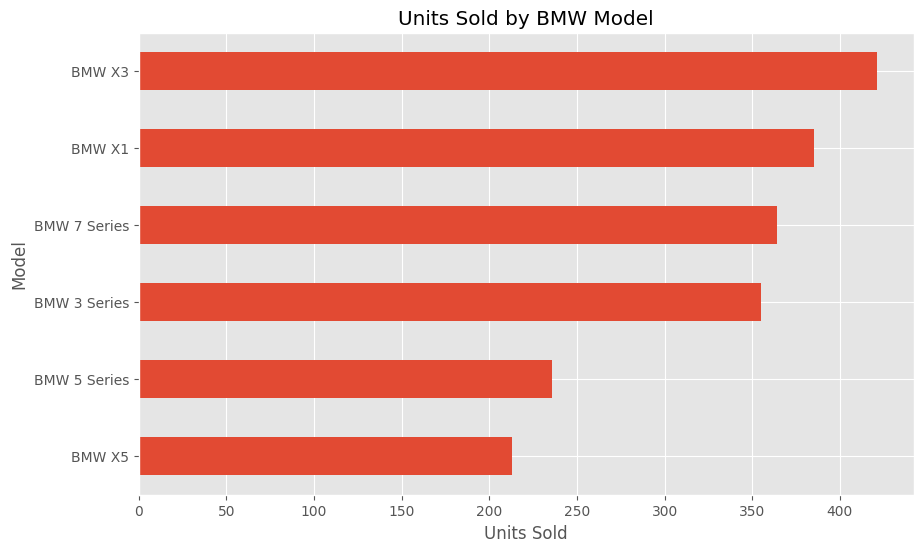

In [10]:
sales=df.groupby("Model")["Units Sold"].sum().sort_values()

plt.figure(figsize=(10,6))

sales.plot(kind="barh")

plt.title("Units Sold by BMW Model")

plt.xlabel("Units Sold")

plt.show()

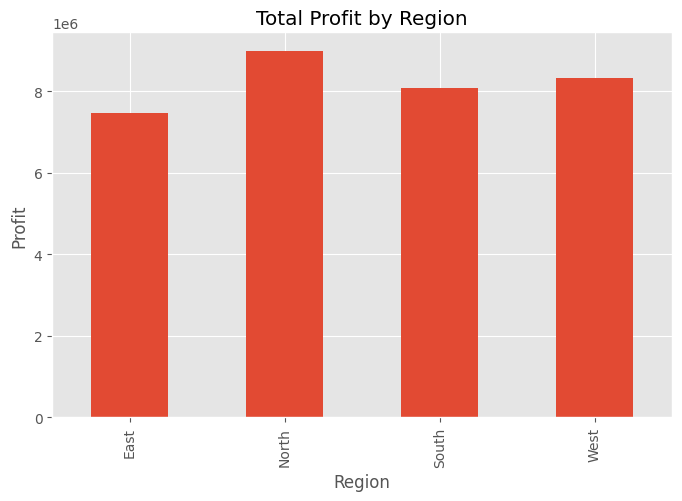

In [11]:
profit=df.groupby("Region")["Profit"].sum()

plt.figure(figsize=(8,5))

profit.plot(kind="bar")

plt.title("Total Profit by Region")

plt.ylabel("Profit")

plt.show()

In [12]:
df["Revenue"]=df["Price"]*df["Units Sold"]

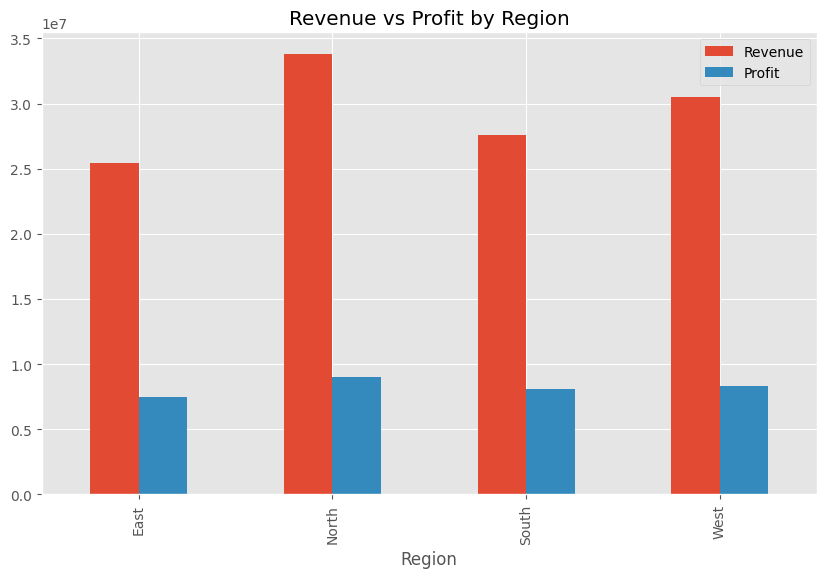

In [13]:
summary=df.groupby("Region")[["Revenue","Profit"]].sum()

summary.plot(kind="bar",figsize=(10,6))

plt.title("Revenue vs Profit by Region")

plt.show()

In [14]:
df["Profit Margin %"]=df["Profit"]/df["Revenue"]*100

In [15]:
df["Profit Margin %"].mean()

np.float64(27.65520179760165)

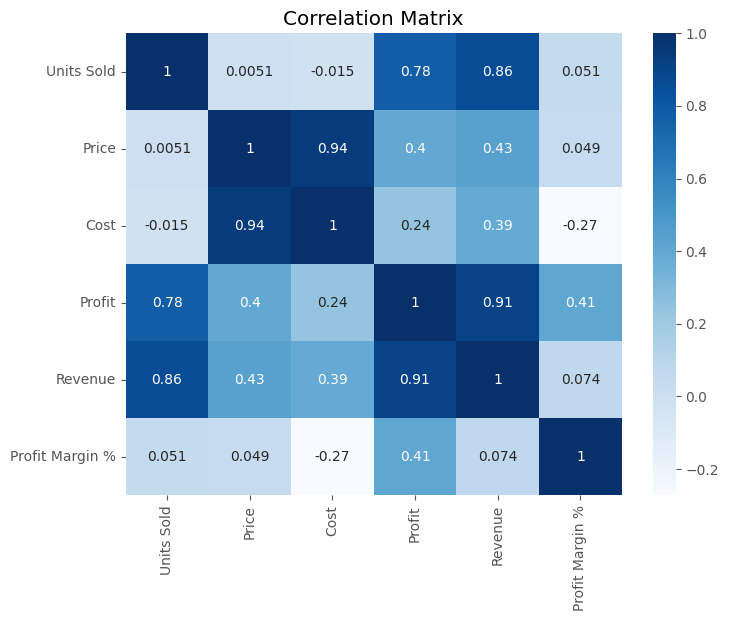

In [16]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="Blues")

plt.title("Correlation Matrix")

plt.show()

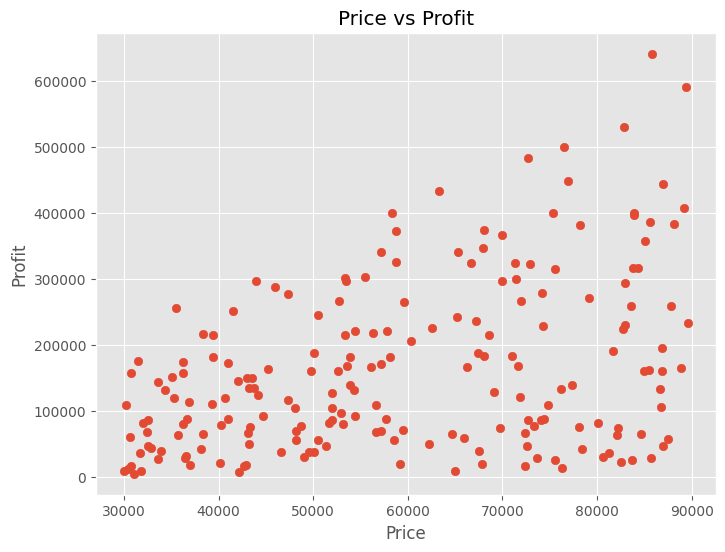

In [17]:
plt.figure(figsize=(8,6))

plt.scatter(df["Price"],df["Profit"])

plt.xlabel("Price")

plt.ylabel("Profit")

plt.title("Price vs Profit")

plt.show()

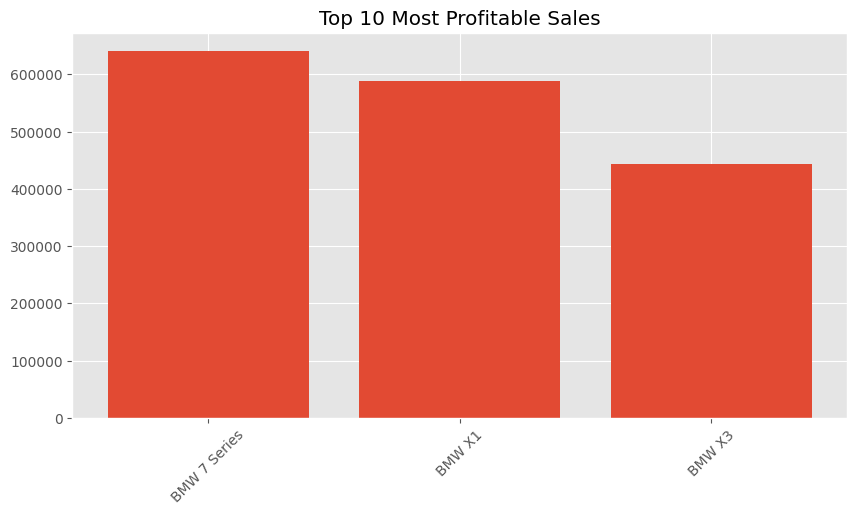

In [18]:
top=df.nlargest(10,"Profit")

plt.figure(figsize=(10,5))

plt.bar(top["Model"],top["Profit"])

plt.xticks(rotation=45)

plt.title("Top 10 Most Profitable Sales")

plt.show()

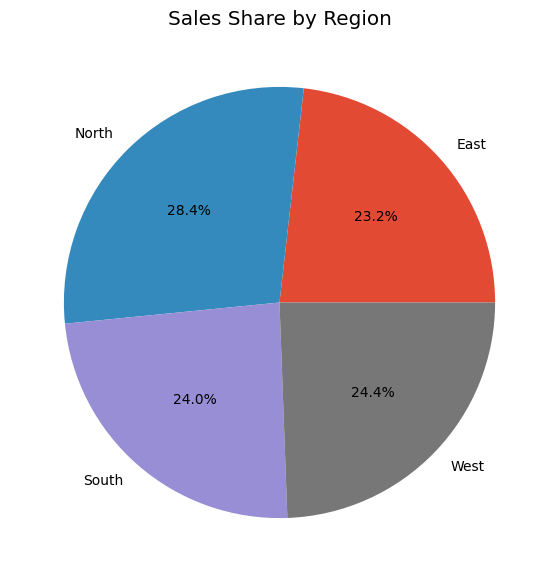

In [19]:
df.groupby("Region")["Units Sold"].sum().plot(
kind="pie",
autopct="%1.1f%%",
figsize=(7,7)
)

plt.ylabel("")

plt.title("Sales Share by Region")

plt.show()

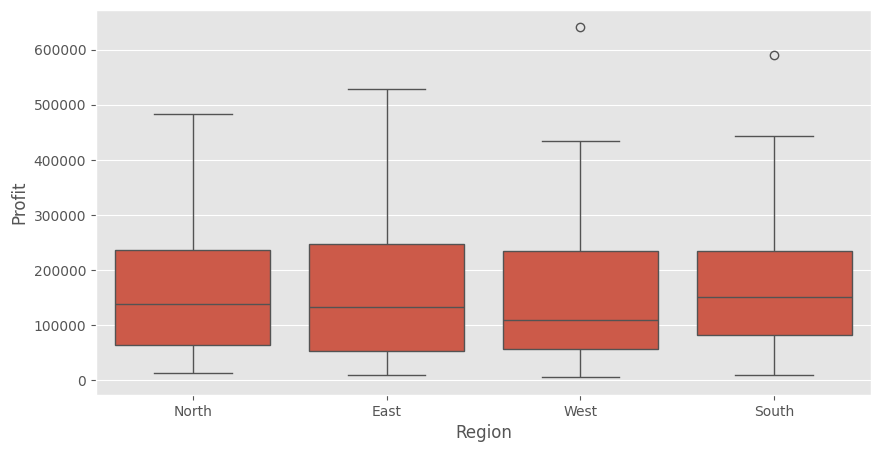

In [20]:
plt.figure(figsize=(10,5))

sns.boxplot(x="Region",y="Profit",data=df)

plt.show()

In [21]:
print("Total Revenue :",df["Revenue"].sum())

print("Total Profit :",df["Profit"].sum())

print("Total Units Sold :",df["Units Sold"].sum())

print("Average Selling Price :",df["Price"].mean())

print("Average Profit Margin :",df["Profit Margin %"].mean())

Total Revenue : 117285097
Total Profit : 32878153.679061234
Total Units Sold : 1974
Average Selling Price : 59360.755
Average Profit Margin : 27.65520179760165
